# Modelo de Clusterização e Ranking de Alunos — Passos Mágicos

Pipeline de agrupamento (KMeans) e classificação (Random Forest) para identificar perfis de alunos e prever o atingimento do Ponto de Virada (PV).

## 1. Imports e Configuração

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings

from models.preprocessing import obter_dados_e_preprocessar
from models.training import treinar_e_agrupar_alunos
from models.ranking import rankear_alunos_individual, rankear_piores_alunos
from models.model_io import save_model

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

## 2. Carregamento e Pré-processamento dos Dados

In [2]:
scaler = StandardScaler()
df_final, cluster_metricas, metricas_normalizadas = obter_dados_e_preprocessar(
    "dataset/PEDE_PASSOS_DATASET_FIAP.csv", scaler
)

# Preenche nomes ausentes com o RA do aluno
df_final["Nome"] = df_final["Nome"].fillna(df_final["RA"])

print(f"Dados carregados: {len(df_final)} alunos")
print(f"Metricas processadas: {len(cluster_metricas)}")

Dados carregados: 3030 alunos
Metricas processadas: 8


## 3. Escolha do K — Elbow Curve e Silhueta

Gerando Elbow Curve...
K=2: Inercia=18877.99, Silhueta=0.3329
K=3: Inercia=16243.51, Silhueta=0.2071
K=4: Inercia=14546.55, Silhueta=0.2045
K=5: Inercia=13289.41, Silhueta=0.2159
K=6: Inercia=12346.18, Silhueta=0.2192
K=7: Inercia=11566.33, Silhueta=0.2267
K=8: Inercia=10971.66, Silhueta=0.2263
K=9: Inercia=10514.16, Silhueta=0.2274
K=10: Inercia=10131.77, Silhueta=0.2272


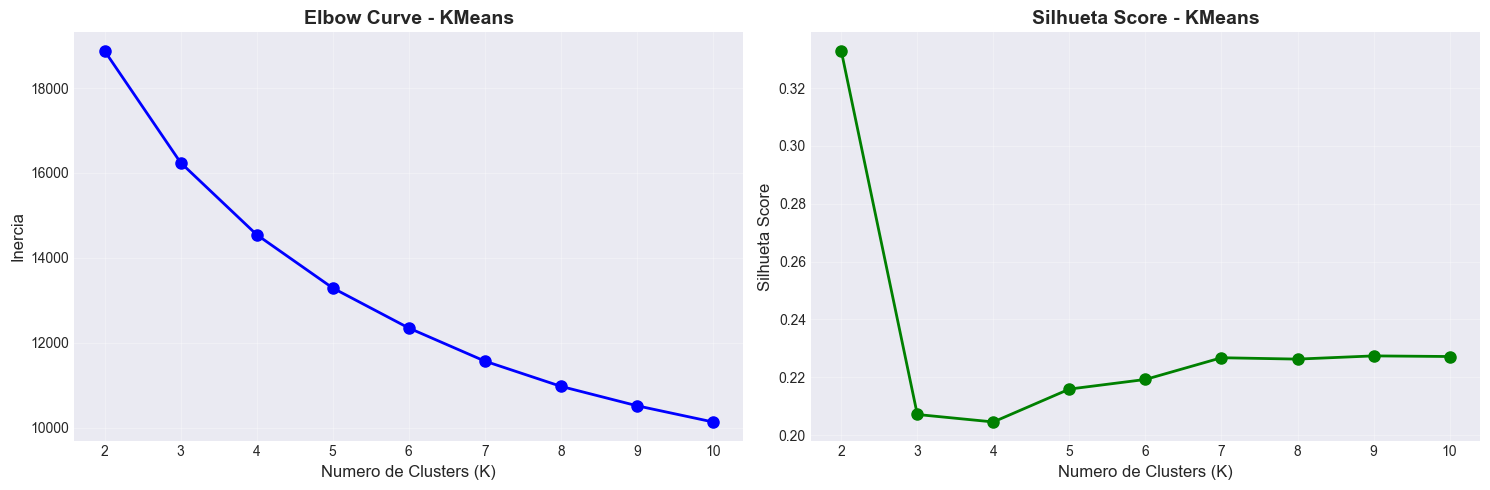

In [3]:
def gerar_elbow_curve(metricas_normalizadas, k_max=10):
    inercias = []
    silhuetas = []
    ks = range(2, k_max + 1)

    for k in ks:
        kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=500)
        kmeans_temp.fit(metricas_normalizadas)
        inercias.append(kmeans_temp.inertia_)
        score = silhouette_score(metricas_normalizadas, kmeans_temp.labels_)
        silhuetas.append(score)
        print(f"K={k}: Inercia={kmeans_temp.inertia_:.2f}, Silhueta={score:.4f}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    ax1.plot(ks, inercias, "bo-", linewidth=2, markersize=8)
    ax1.set_xlabel("Numero de Clusters (K)", fontsize=12)
    ax1.set_ylabel("Inercia", fontsize=12)
    ax1.set_title("Elbow Curve - KMeans", fontsize=14, fontweight="bold")
    ax1.grid(True, alpha=0.3)

    ax2.plot(ks, silhuetas, "go-", linewidth=2, markersize=8)
    ax2.set_xlabel("Numero de Clusters (K)", fontsize=12)
    ax2.set_ylabel("Silhueta Score", fontsize=12)
    ax2.set_title("Silhueta Score - KMeans", fontsize=14, fontweight="bold")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return inercias, silhuetas

print("Gerando Elbow Curve...")
inercias, silhuetas = gerar_elbow_curve(metricas_normalizadas, k_max=10)

## 4. Funções de Treinamento e Visualização

In [4]:
def treinar_notebook(df, cluster_metricas, metricas_normalizadas, n_clusters=4):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=20, max_iter=500, tol=1e-4)
    df["Grupo_ID"] = kmeans.fit_predict(metricas_normalizadas)

    ranking = df.groupby("Grupo_ID")["INDE_FINAL"].mean().sort_values().index.tolist()
    mapa_grupos = {idx: f"Nivel {i+1}" for i, idx in enumerate(ranking)}
    df["Perfil_Nivel"] = df["Grupo_ID"].map(mapa_grupos)

    df["Alvo_PV"] = df["Atingiu PV"].apply(
        lambda x: 1 if str(x).strip().upper() == "SIM" else 0
    )

    from sklearn.ensemble import RandomForestClassifier
    from sklearn.model_selection import train_test_split

    metricas = df[cluster_metricas]
    alvo = df["Alvo_PV"]

    X_train, X_test, y_train, y_test = train_test_split(
        metricas, alvo, test_size=0.2, random_state=42
    )

    modelo_rf = RandomForestClassifier(
        n_estimators=150, min_samples_leaf=4, max_features="sqrt", random_state=42
    )
    modelo_rf.fit(X_train, y_train)

    df["Probabilidade_PV"] = modelo_rf.predict_proba(metricas)[:, 1]

    return df, modelo_rf, kmeans, ranking

In [5]:
from sklearn.manifold import TSNE

def visualizar_distribuicao_grupos(df, metricas_normalizadas, n_clusters):
    """Visualiza clusters lado a lado: t-SNE e PCA."""
    fig, axes = plt.subplots(1, 2, figsize=(22, 8))

    grupos_unicos = sorted(df["Grupo_ID"].unique())
    cores = plt.cm.Set1(np.linspace(0, 1, n_clusters))

    # Reset index para alinhar com numpy array
    grupo_ids = df["Grupo_ID"].values
    perfil_niveis = df["Perfil_Nivel"].values

    for ax, titulo_metodo in zip(axes, ["t-SNE", "PCA"]):
        if titulo_metodo == "t-SNE":
            tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
            pts = tsne.fit_transform(metricas_normalizadas)
            lbl_x, lbl_y = "t-SNE 1", "t-SNE 2"
        else:
            pca = PCA(n_components=2)
            pts = pca.fit_transform(metricas_normalizadas)
            lbl_x = f"PC1 ({pca.explained_variance_ratio_[0]:.1%})"
            lbl_y = f"PC2 ({pca.explained_variance_ratio_[1]:.1%})"

        for i, grupo in enumerate(grupos_unicos):
            mascara = grupo_ids == grupo
            nivel = perfil_niveis[mascara][0]
            ax.scatter(
                pts[mascara, 0], pts[mascara, 1],
                c=[cores[i]], label=f"{nivel} (n={mascara.sum()})",
                s=60, alpha=0.6, edgecolors="white", linewidth=0.3,
            )
            cx, cy = pts[mascara, 0].mean(), pts[mascara, 1].mean()
            ax.annotate(nivel, (cx, cy), fontsize=11, fontweight="bold",
                        ha="center", va="center",
                        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

        ax.set_xlabel(lbl_x, fontsize=11)
        ax.set_ylabel(lbl_y, fontsize=11)
        ax.set_title(f"{titulo_metodo} — {n_clusters} clusters", fontsize=13, fontweight="bold")
        ax.legend(loc="upper left", fontsize=9)
        ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

## 5. Análise Comparativa — K=3, K=4 e K=5

ANALISANDO K=3 CLUSTERS

--- Estatisticas por Grupo (K=3) ---
              Quantidade  INDE_Media  INDE_StdDev  Prob_PV_Media  Prob_PV_Min  \
Perfil_Nivel                                                                    
Nivel 1              442        6.55         0.84           0.00          0.0   
Nivel 2             1402        7.56         0.23           0.05          0.0   
Nivel 3             1186        7.76         0.44           0.03          0.0   

              Prob_PV_Max  Atingiram_PV  
Perfil_Nivel                             
Nivel 1              0.10             0  
Nivel 2              0.53            70  
Nivel 3              0.52            43  


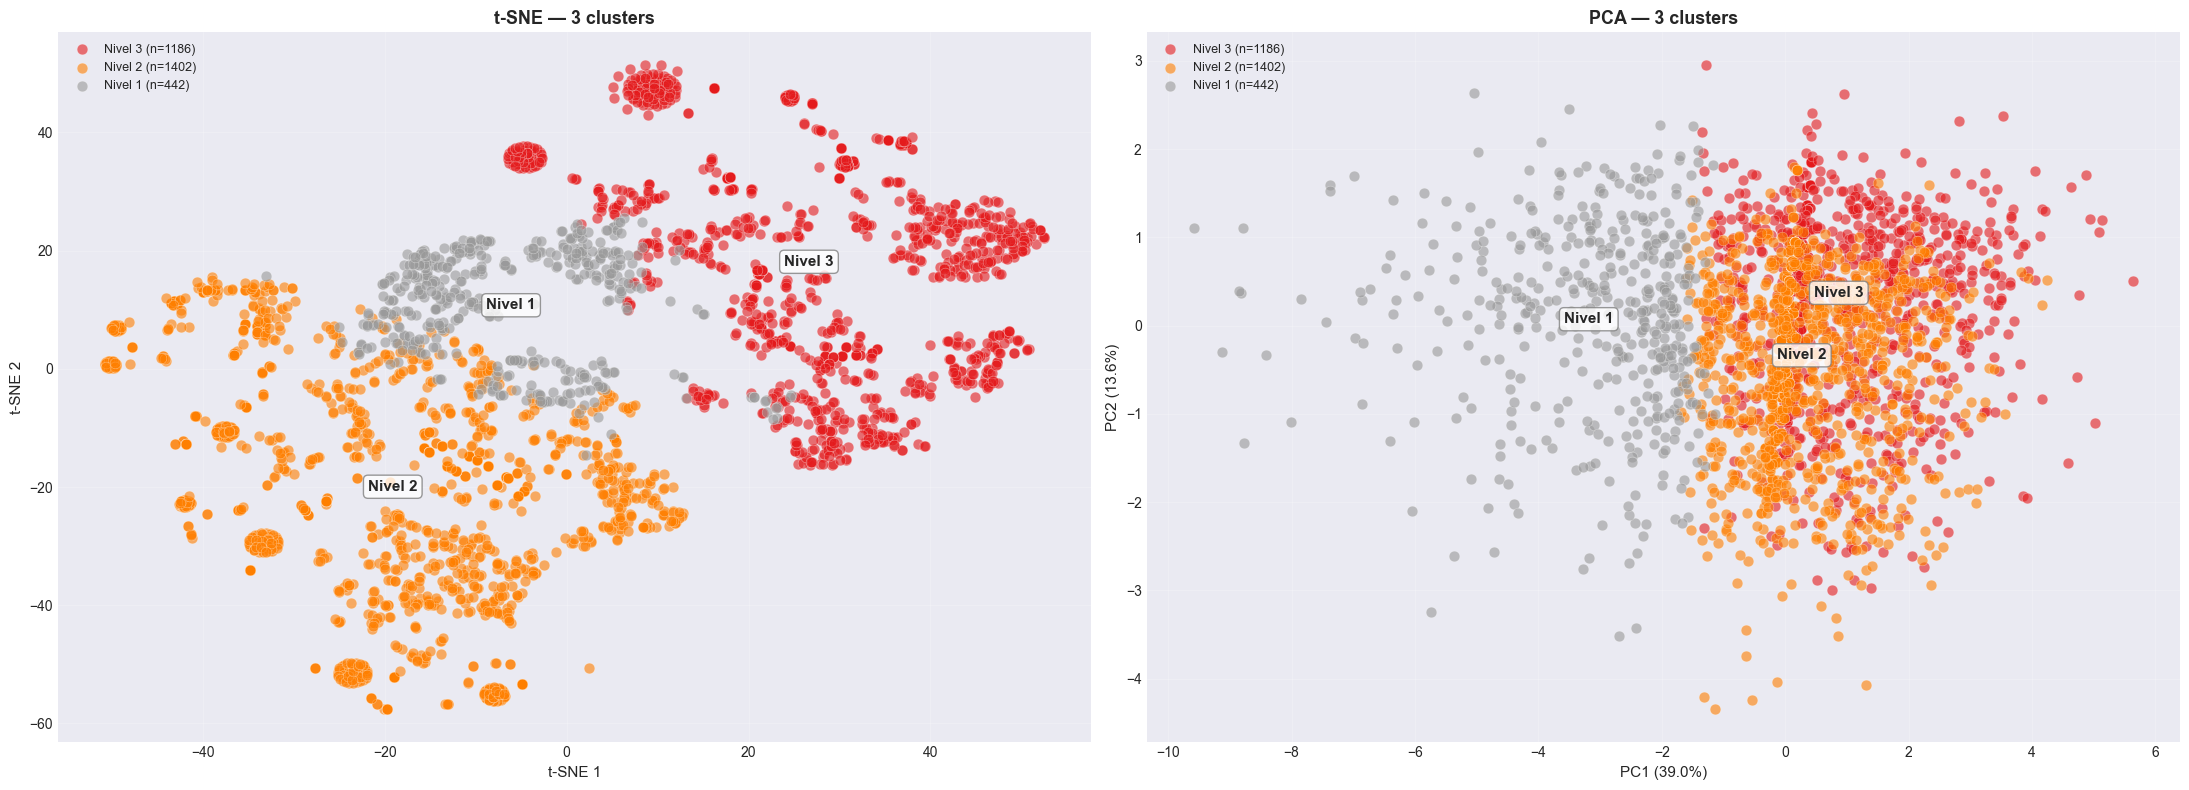

In [6]:
print("=" * 60)
print("ANALISANDO K=3 CLUSTERS")
print("=" * 60)

df_k3 = df_final.copy()
df_k3, modelo_k3, kmeans_k3, ranking_k3 = treinar_notebook(
    df_k3, cluster_metricas, metricas_normalizadas, n_clusters=3
)

print("\n--- Estatisticas por Grupo (K=3) ---")
stats_k3 = df_k3.groupby("Perfil_Nivel").agg({
    "Nome": "count",
    "INDE_FINAL": ["mean", "std"],
    "Probabilidade_PV": ["mean", "min", "max"],
    "Alvo_PV": "sum",
}).round(2)
stats_k3.columns = [
    "Quantidade", "INDE_Media", "INDE_StdDev",
    "Prob_PV_Media", "Prob_PV_Min", "Prob_PV_Max", "Atingiram_PV",
]
print(stats_k3)

visualizar_distribuicao_grupos(df_k3, metricas_normalizadas, 3)

ANALISANDO K=4 CLUSTERS

--- Estatisticas por Grupo (K=4) ---
              Quantidade  INDE_Media  INDE_StdDev  Prob_PV_Media  Prob_PV_Min  \
Perfil_Nivel                                                                    
Nivel 1              325        6.31         0.83           0.00          0.0   
Nivel 2             1220        7.49         0.21           0.06          0.0   
Nivel 3              898        7.60         0.23           0.04          0.0   
Nivel 4              587        7.98         0.54           0.00          0.0   

              Prob_PV_Max  Atingiram_PV  
Perfil_Nivel                             
Nivel 1              0.10             0  
Nivel 2              0.53            70  
Nivel 3              0.52            43  
Nivel 4              0.15             0  


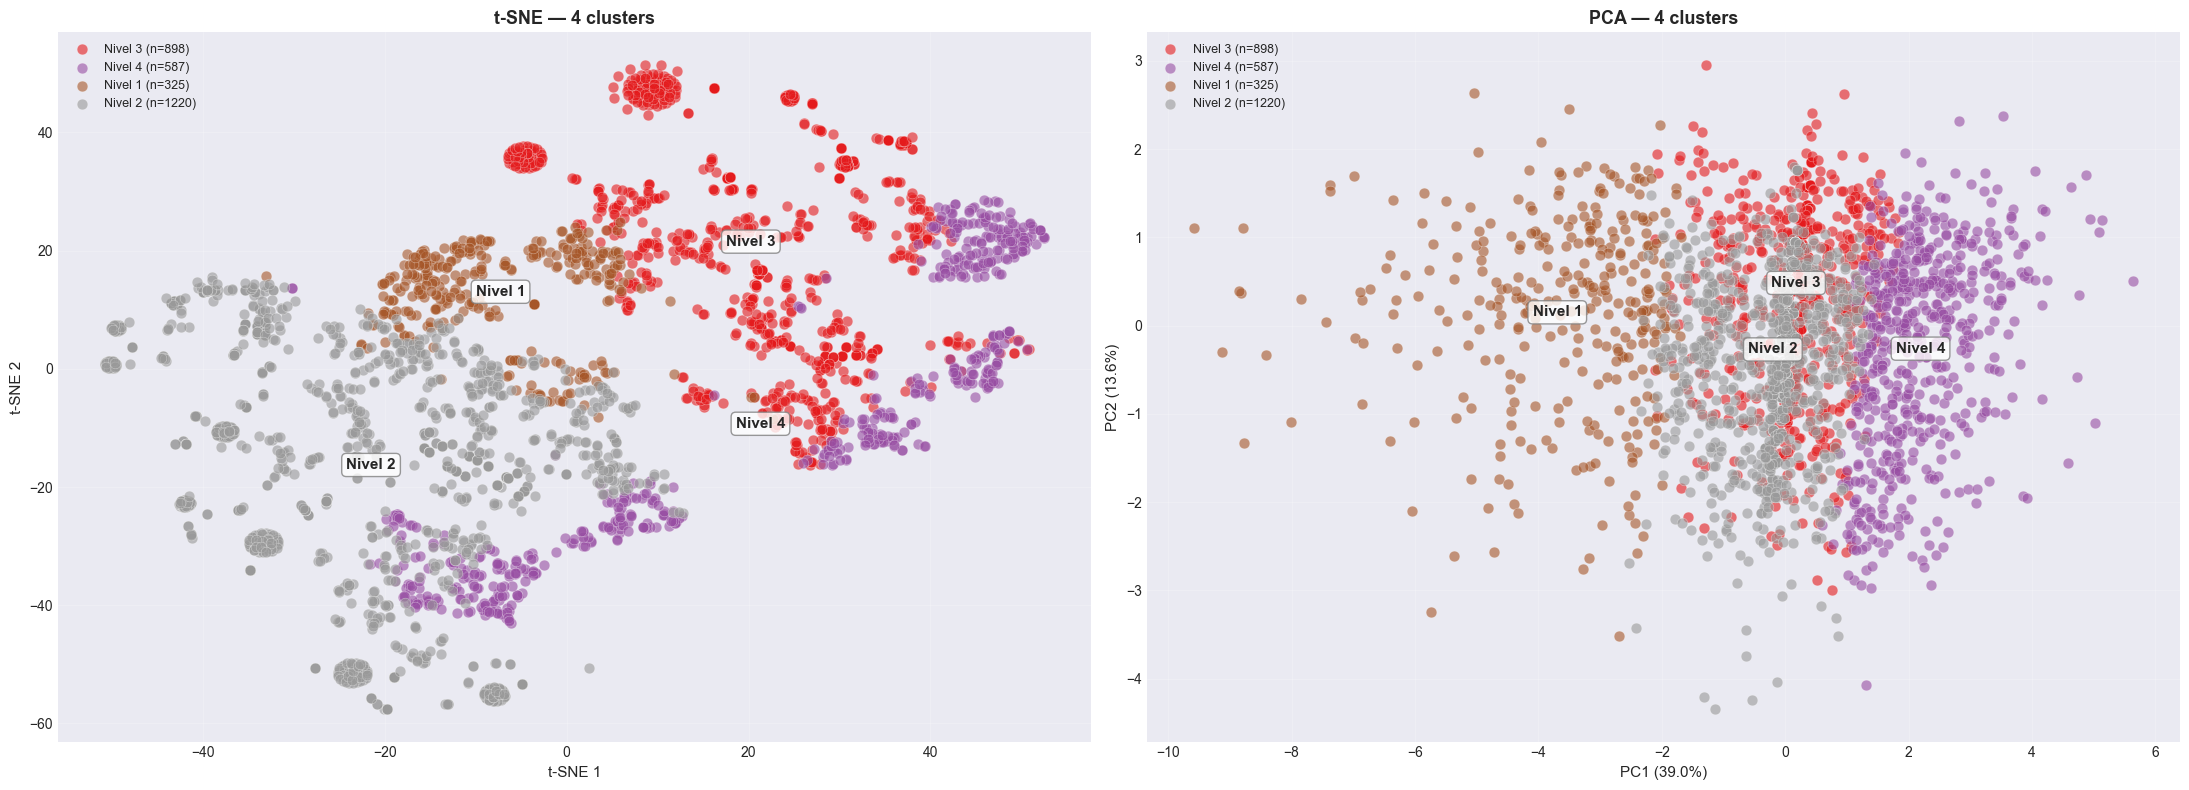

In [7]:
print("=" * 60)
print("ANALISANDO K=4 CLUSTERS")
print("=" * 60)

df_k4 = df_final.copy()
df_k4, modelo_k4, kmeans_k4, ranking_k4 = treinar_notebook(
    df_k4, cluster_metricas, metricas_normalizadas, n_clusters=4
)

print("\n--- Estatisticas por Grupo (K=4) ---")
stats_k4 = df_k4.groupby("Perfil_Nivel").agg({
    "Nome": "count",
    "INDE_FINAL": ["mean", "std"],
    "Probabilidade_PV": ["mean", "min", "max"],
    "Alvo_PV": "sum",
}).round(2)
stats_k4.columns = [
    "Quantidade", "INDE_Media", "INDE_StdDev",
    "Prob_PV_Media", "Prob_PV_Min", "Prob_PV_Max", "Atingiram_PV",
]
print(stats_k4)

visualizar_distribuicao_grupos(df_k4, metricas_normalizadas, 4)

ANALISANDO K=5 CLUSTERS

--- Estatisticas por Grupo (K=5) ---
              Quantidade  INDE_Media  INDE_StdDev  Prob_PV_Media  Prob_PV_Min  \
Perfil_Nivel                                                                    
Nivel 1              318        6.30         0.83           0.00          0.0   
Nivel 2             1096        7.49         0.20           0.06          0.0   
Nivel 3              409        7.53         0.19           0.00          0.0   
Nivel 4              767        7.60         0.23           0.05          0.0   
Nivel 5              440        8.14         0.55           0.00          0.0   

              Prob_PV_Max  Atingiram_PV  
Perfil_Nivel                             
Nivel 1              0.10             0  
Nivel 2              0.53            70  
Nivel 3              0.13             2  
Nivel 4              0.52            41  
Nivel 5              0.15             0  


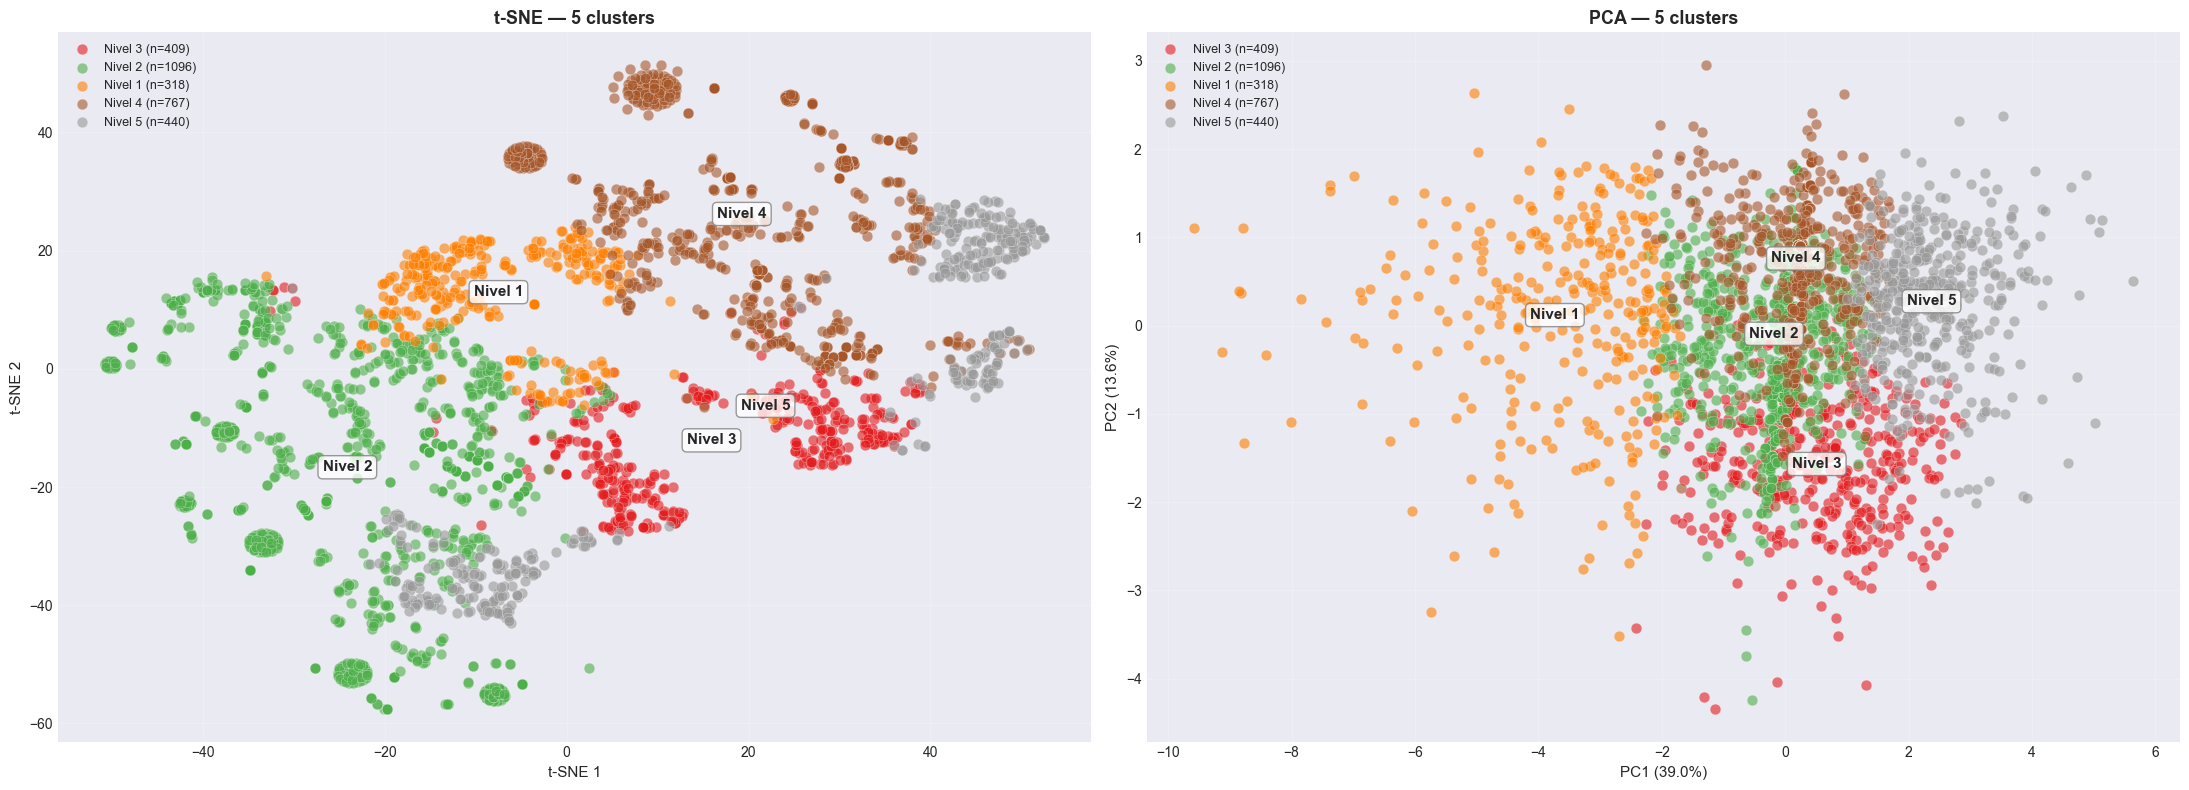

In [8]:
print("=" * 60)
print("ANALISANDO K=5 CLUSTERS")
print("=" * 60)

df_k5 = df_final.copy()
df_k5, modelo_k5, kmeans_k5, ranking_k5 = treinar_notebook(
    df_k5, cluster_metricas, metricas_normalizadas, n_clusters=5
)

print("\n--- Estatisticas por Grupo (K=5) ---")
stats_k5 = df_k5.groupby("Perfil_Nivel").agg({
    "Nome": "count",
    "INDE_FINAL": ["mean", "std"],
    "Probabilidade_PV": ["mean", "min", "max"],
    "Alvo_PV": "sum",
}).round(2)
stats_k5.columns = [
    "Quantidade", "INDE_Media", "INDE_StdDev",
    "Prob_PV_Media", "Prob_PV_Min", "Prob_PV_Max", "Atingiram_PV",
]
print(stats_k5)

visualizar_distribuicao_grupos(df_k5, metricas_normalizadas, 5)

ANALISANDO K=6 CLUSTERS

--- Estatisticas por Grupo (K=6) ---
              Quantidade  INDE_Media  INDE_StdDev  Prob_PV_Media  Prob_PV_Min  \
Perfil_Nivel                                                                    
Nivel 1              302        6.25         0.82           0.00          0.0   
Nivel 2              312        7.45         0.26           0.04          0.0   
Nivel 3              928        7.51         0.20           0.06          0.0   
Nivel 4              372        7.53         0.19           0.00          0.0   
Nivel 5              722        7.60         0.23           0.05          0.0   
Nivel 6              394        8.18         0.56           0.00          0.0   

              Prob_PV_Max  Atingiram_PV  
Perfil_Nivel                             
Nivel 1              0.10             0  
Nivel 2              0.40            11  
Nivel 3              0.53            63  
Nivel 4              0.06             1  
Nivel 5              0.52            

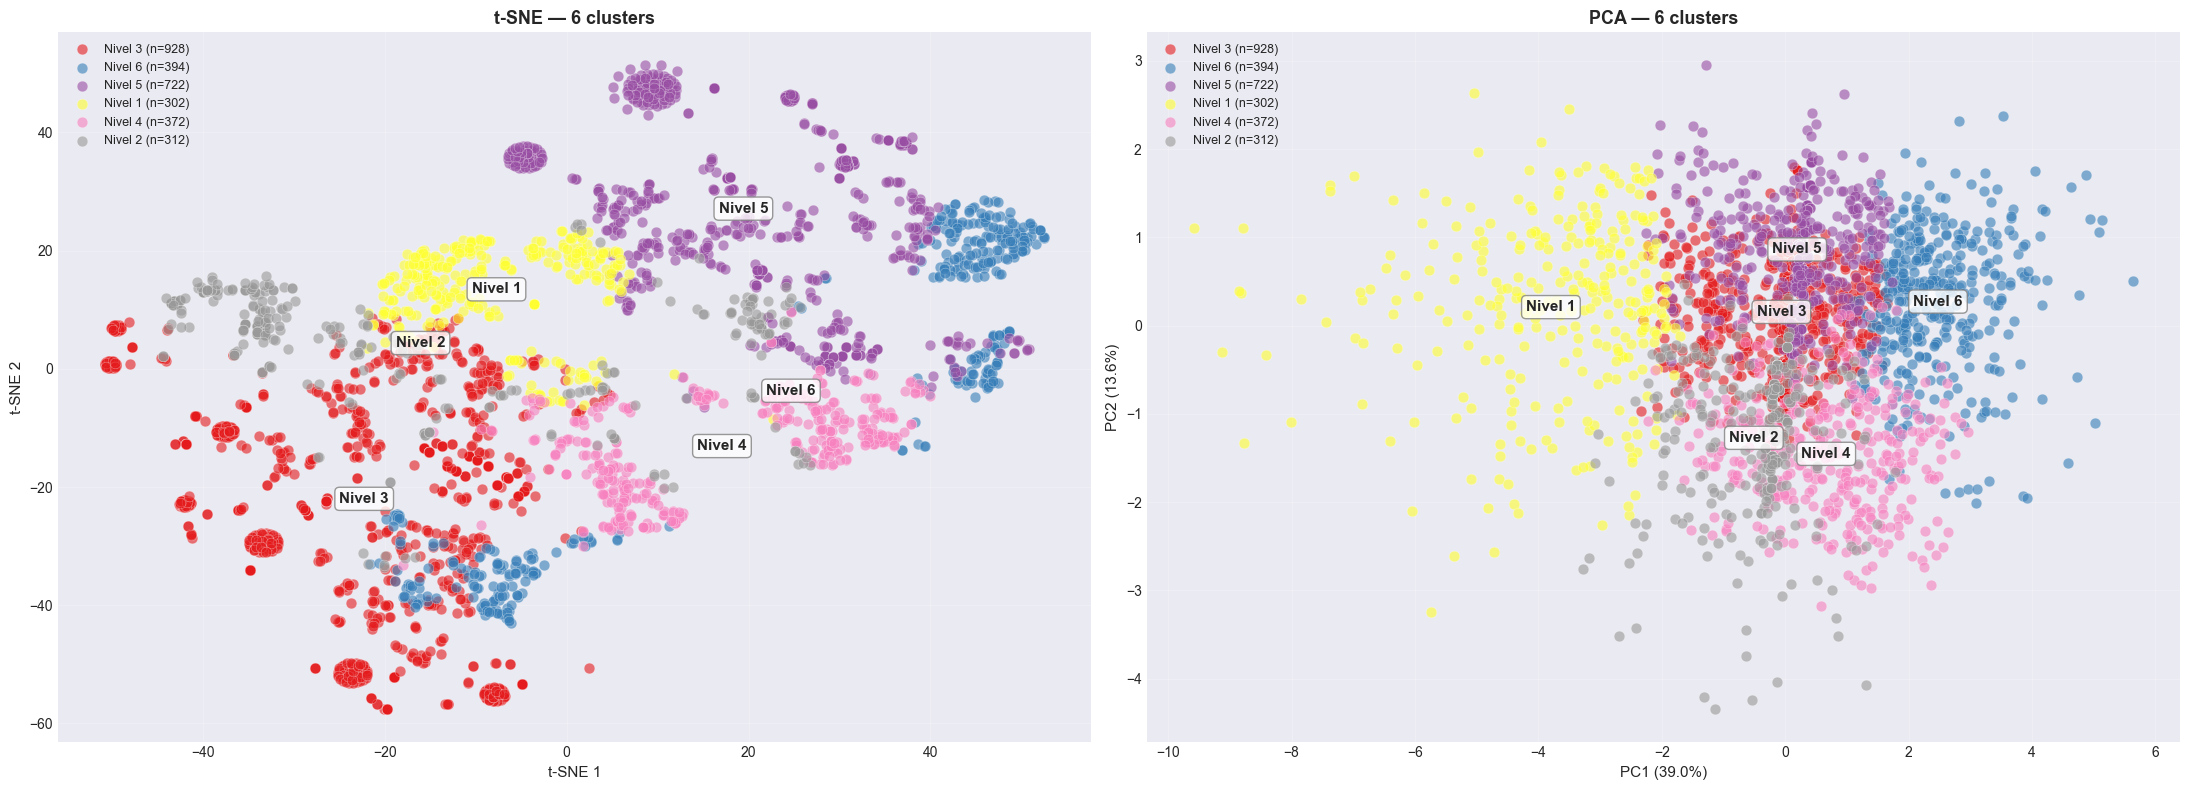

In [9]:
print("=" * 60)
print("ANALISANDO K=6 CLUSTERS")
print("=" * 60)

df_k6 = df_final.copy()
df_k6, modelo_k6, kmeans_k6, ranking_k6 = treinar_notebook(
    df_k6, cluster_metricas, metricas_normalizadas, n_clusters=6
)

print("\n--- Estatisticas por Grupo (K=6) ---")
stats_k6 = df_k6.groupby("Perfil_Nivel").agg({
    "Nome": "count",
    "INDE_FINAL": ["mean", "std"],
    "Probabilidade_PV": ["mean", "min", "max"],
    "Alvo_PV": "sum",
}).round(2)
stats_k6.columns = [
    "Quantidade", "INDE_Media", "INDE_StdDev",
    "Prob_PV_Media", "Prob_PV_Min", "Prob_PV_Max", "Atingiram_PV",
]
print(stats_k6)

visualizar_distribuicao_grupos(df_k6, metricas_normalizadas, 6)

## 6. Comparação dos Modelos

In [10]:
print("=" * 60)
print("COMPARACAO DOS MODELOS")
print("=" * 60)

from sklearn.metrics import silhouette_score

resultados = []
for label, df_temp, km in [("K=3", df_k3, kmeans_k3), ("K=4", df_k4, kmeans_k4),
                             ("K=5", df_k5, kmeans_k5), ("K=6", df_k6, kmeans_k6)]:
    sil = silhouette_score(metricas_normalizadas, df_temp["Grupo_ID"])
    resultados.append({
        "": label,
        "Clusters": len(df_temp["Grupo_ID"].unique()),
        "Silhueta": round(sil, 4),
        "Atingiram PV": f"{df_temp['Alvo_PV'].sum()}/{len(df_temp)} ({df_temp['Alvo_PV'].sum()/len(df_temp)*100:.1f}%)",
    })

comparacao = pd.DataFrame(resultados).set_index("")
print(comparacao)

COMPARACAO DOS MODELOS
     Clusters  Silhueta     Atingiram PV
                                        
K=3         3    0.2071  113/3030 (3.7%)
K=4         4    0.2045  113/3030 (3.7%)
K=5         5    0.2159  113/3030 (3.7%)
K=6         6    0.2192  113/3030 (3.7%)


## 7. Alunos em Risco e Distribuição de Probabilidades

TOP 10 ALUNOS COM MAIOR RISCO (K=4)
           RA     Nome Perfil_Nivel  INDE_FINAL  Probabilidade_PV
2591  RA-1116  RA-1116      Nivel 1    3.789478               0.0
2442   RA-484   RA-484      Nivel 1    3.835478               0.0
2147   RA-672   RA-672      Nivel 1    4.211814               0.0
2667   RA-392   RA-392      Nivel 1    4.363946               0.0
2270   RA-497   RA-497      Nivel 1    4.496081               0.0
2089   RA-750   RA-750      Nivel 1    4.542230               0.0
2534  RA-1532  RA-1532      Nivel 1    4.548545               0.0
2511  RA-1530  RA-1530      Nivel 1    4.639154               0.0
1909   RA-863   RA-863      Nivel 1    4.668435               0.0
2416   RA-798   RA-798      Nivel 1    4.674365               0.0


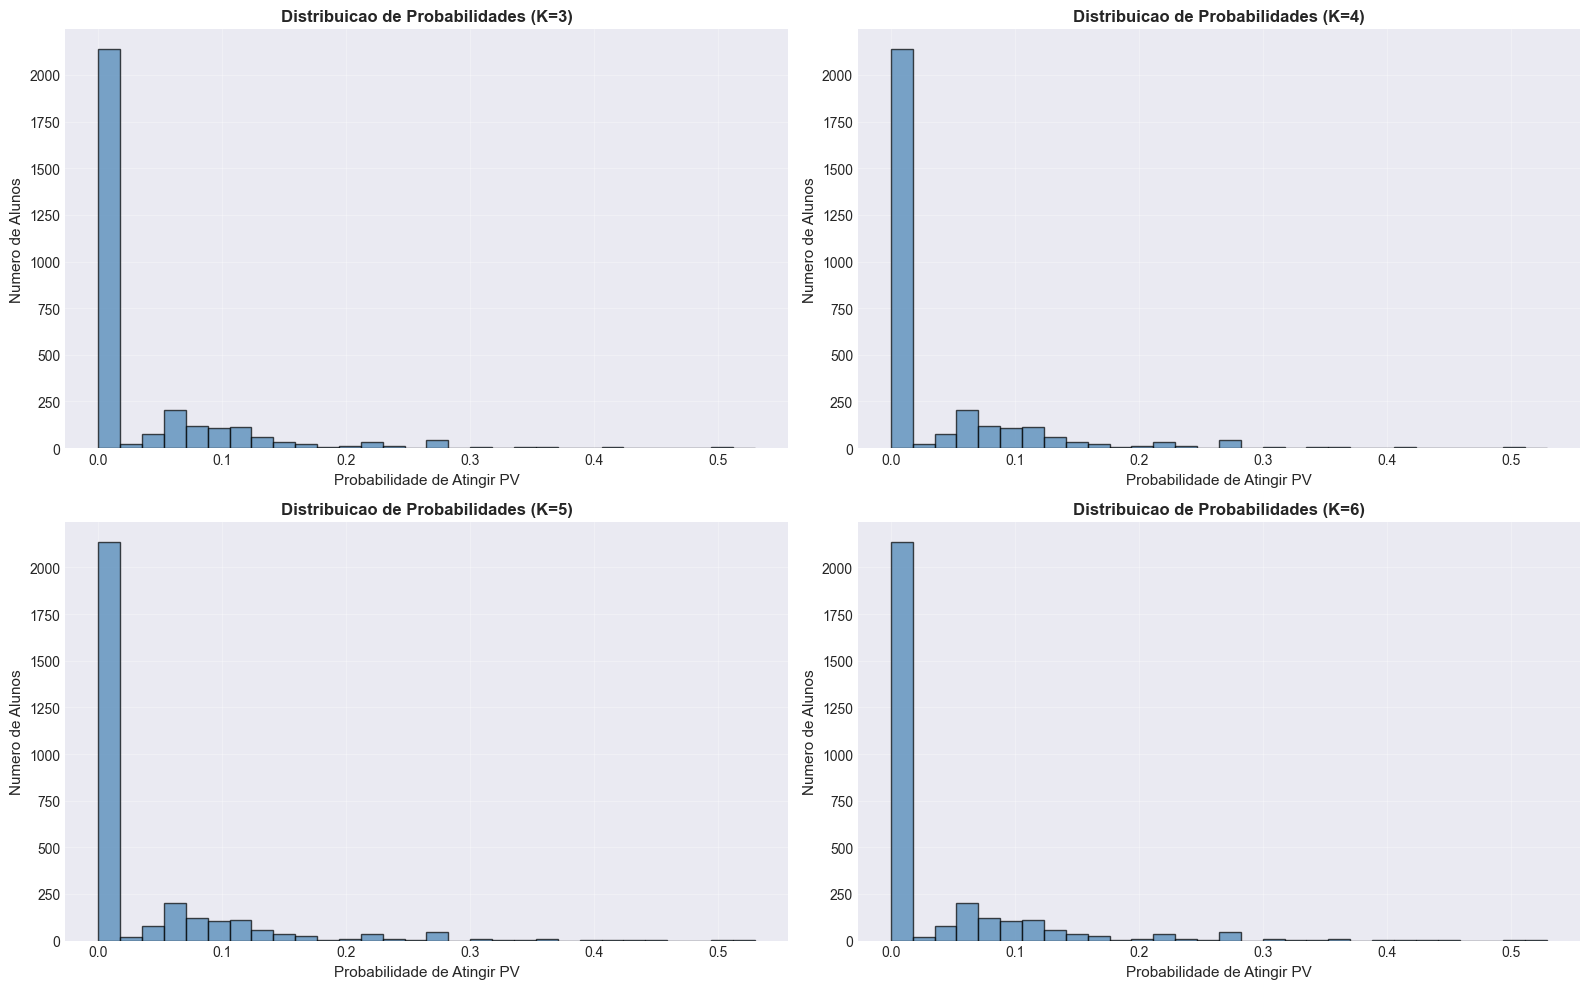

In [11]:
print("=" * 60)
print("TOP 10 ALUNOS COM MAIOR RISCO (K=4)")
print("=" * 60)

alunos_risco = (
    df_k4[df_k4["Alvo_PV"] == 0]
    .sort_values(by=["Probabilidade_PV", "INDE_FINAL"])
    .head(10)
)
print(alunos_risco[["RA", "Nome", "Perfil_Nivel", "INDE_FINAL", "Probabilidade_PV"]].to_string())

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, (df_temp, k) in enumerate([(df_k3, 3), (df_k4, 4), (df_k5, 5), (df_k6, 6)]):
    axes[idx].hist(
        df_temp["Probabilidade_PV"], bins=30, edgecolor="black", alpha=0.7, color="steelblue"
    )
    axes[idx].set_xlabel("Probabilidade de Atingir PV", fontsize=11)
    axes[idx].set_ylabel("Numero de Alunos", fontsize=11)
    axes[idx].set_title(f"Distribuicao de Probabilidades (K={k})", fontsize=12, fontweight="bold")
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Ranking Individual — Top 20 Melhores e Piores Alunos

In [12]:
print("=" * 60)
print("TOP 20 MELHORES ALUNOS - RANKING INDIVIDUAL (K=4)")
print("=" * 60)

ranking_k4_df = rankear_alunos_individual(df_k4, cluster_metricas)
top_20 = ranking_k4_df.nlargest(20, "Score_Individual")[
    ["RA", "Nome", "Perfil_Nivel", "Score_Individual", "Ranking_Geral", "Probabilidade_PV"]
]
print(top_20.to_string())

print("\n")
print("=" * 60)
print("TOP 20 PIORES ALUNOS - RANKING INDIVIDUAL (K=4)")
print("=" * 60)

bottom_20 = rankear_piores_alunos(df_k4, cluster_metricas, n=20)[
    ["RA", "Nome", "Perfil_Nivel", "Score_Individual", "Ranking_Geral", "Probabilidade_PV"]
]
print(bottom_20.to_string())

TOP 20 MELHORES ALUNOS - RANKING INDIVIDUAL (K=4)
           RA     Nome Perfil_Nivel  Score_Individual  Ranking_Geral  Probabilidade_PV
2278  RA-1023  RA-1023      Nivel 4          9.488644              1          0.014275
2900    RA-87    RA-87      Nivel 4          9.422256              2          0.008349
2424  RA-1510  RA-1510      Nivel 4          9.417017              3          0.000000
2449   RA-487   RA-487      Nivel 4          9.413509              4          0.009608
2206   RA-958   RA-958      Nivel 4          9.385572              5          0.000000
2531   RA-557   RA-557      Nivel 4          9.357740              6          0.000000
2348   RA-829   RA-829      Nivel 4          9.240634              7          0.012942
2896    RA-56    RA-56      Nivel 4          9.210234              8          0.073685
2465  RA-1096  RA-1096      Nivel 4          9.204006              9          0.000000
1991  RA-1344  RA-1344      Nivel 4          9.193525             10          0.

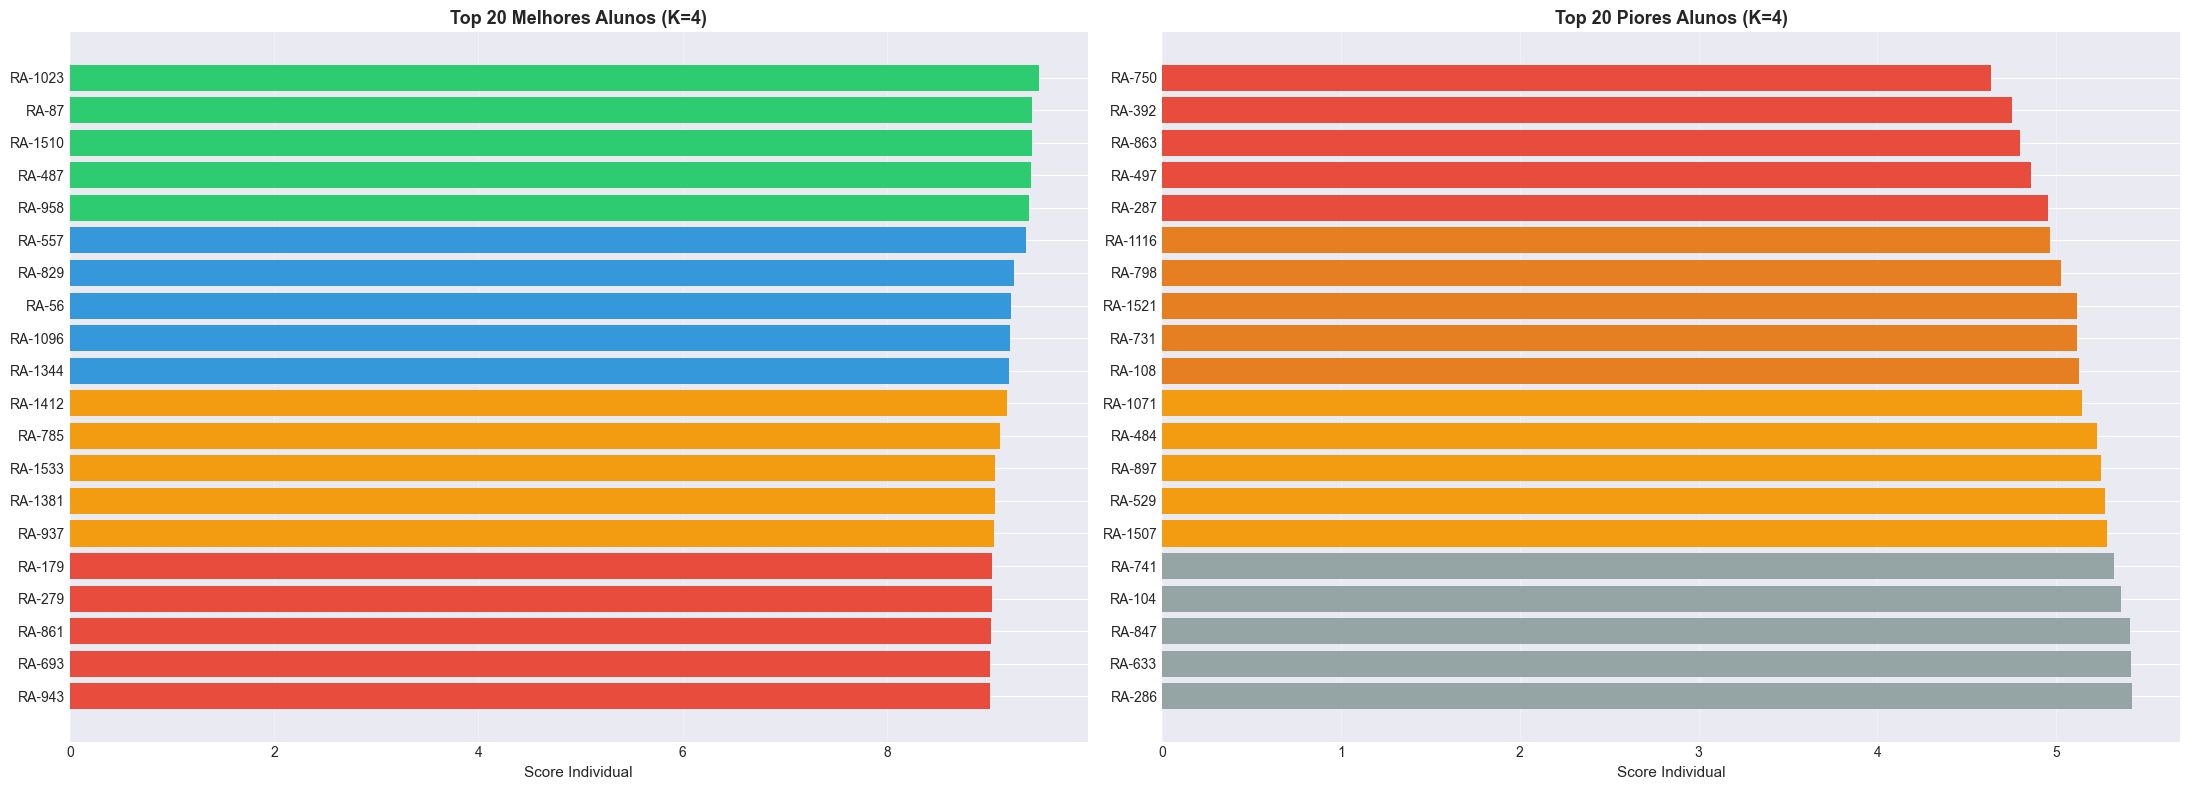

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))

# --- Melhores ---
top_20_plot = top_20.reset_index(drop=True)
labels_top = top_20_plot["RA"].astype(str)
cores_top = [
    "#2ecc71" if x <= 5 else "#3498db" if x <= 10 else "#f39c12" if x <= 15 else "#e74c3c"
    for x in top_20_plot["Ranking_Geral"]
]
ax1.barh(range(len(top_20_plot)), top_20_plot["Score_Individual"], color=cores_top)
ax1.set_yticks(range(len(top_20_plot)))
ax1.set_yticklabels(labels_top, fontsize=10)
ax1.set_xlabel("Score Individual", fontsize=11)
ax1.set_title("Top 20 Melhores Alunos (K=4)", fontsize=13, fontweight="bold")
ax1.invert_yaxis()
ax1.grid(True, alpha=0.3, axis="x")

# --- Piores ---
bottom_20_plot = bottom_20.reset_index(drop=True)
labels_bot = bottom_20_plot["RA"].astype(str)
cores_bot = [
    "#e74c3c" if x <= 5 else "#e67e22" if x <= 10 else "#f39c12" if x <= 15 else "#95a5a6"
    for x in bottom_20_plot["Ranking_Geral"]
]
ax2.barh(range(len(bottom_20_plot)), bottom_20_plot["Score_Individual"], color=cores_bot)
ax2.set_yticks(range(len(bottom_20_plot)))
ax2.set_yticklabels(labels_bot, fontsize=10)
ax2.set_xlabel("Score Individual", fontsize=11)
ax2.set_title("Top 20 Piores Alunos (K=4)", fontsize=13, fontweight="bold")
ax2.invert_yaxis()
ax2.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()